In [1]:
import numpy as np
import healpy as hp
from healpy.newvisufunc import projview
from astropy.table import Table

import matplotlib
from matplotlib import pyplot as plt

from Corrfunc import mocks
from Corrfunc.utils import convert_rp_pi_counts_to_wp
from scipy import constants
from scipy import stats
import scipy.interpolate as interp
from random import sample
import matplotlib.gridspec as gridspec
from Corrfunc import theory
from astropy.cosmology import FlatLambdaCDM
from Corrfunc.utils import convert_3d_counts_to_cf
import astropy.cosmology.units as cu
import astropy.units as u
import site
site.addsitedir('/oak/stanford/orgs/kipac/users/mahlet/quaia_bias/scripts') 
import quaia
import quaia_debug
from astropy.coordinates import SkyCoord
import matplotlib.gridspec as gridspec
import seaborn as sns
from matplotlib.colors import LogNorm
import matplotlib.patches as mpatches
from tqdm import trange

In [2]:
matplotlib.rcParams['ytick.labelsize'] = 18
matplotlib.rcParams['xtick.labelsize'] = 18
matplotlib.rcParams['axes.labelsize'] = 22
matplotlib.rcParams['legend.fontsize'] = 18
matplotlib.rcParams['axes.titlesize'] = 20

# Load data from local machine

In [3]:
fn_sello = f'../data/maps/selection_function_NSIDE64_G20.0.fits'
fn_selhi = f'../data/maps/selection_function_NSIDE64_G20.5.fits'

## Parameters

In [4]:
NSIDE = 64
NPIX = hp.nside2npix(NSIDE)

In [5]:
G_hi = 20.5

In [6]:
nthreads = 18

In [7]:
mask_type = 'selfunc'

# Visuals

In [8]:
tab_datahi, pixel_indices_datahi_mask, N_datahi_mask, mask_datahi = quaia.read(f'../data/quaia_G20.5.fits', G_hi, fn_selhi, mask_type = 'selfunc')

Number of data sources: 1295502
{'NAME': '\\emph{{Gaia}}--\\emph{{unWISE}} Quasar Catalog', 'ABBRV': 'Quaia'}
Column names: <TableColumns names=('source_id','unwise_objid','redshift_quaia','redshift_quaia_err','ra','dec','l','b','phot_g_mean_mag','phot_bp_mean_mag','phot_rp_mean_mag','mag_w1_vg','mag_w2_vg','pm','pmra','pmdec','pmra_error','pmdec_error')>


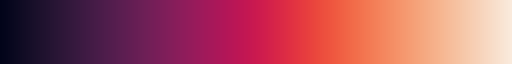

In [9]:
cmap = sns.color_palette("rocket", as_cmap=True)
cmap

In [10]:
zbin_array = [0.0,1.0,2.0,3.0,4.0]

<>:18: SyntaxWarning: invalid escape sequence '\m'
<>:26: SyntaxWarning: invalid escape sequence '\m'
<>:18: SyntaxWarning: invalid escape sequence '\m'
<>:26: SyntaxWarning: invalid escape sequence '\m'
/tmp/ipykernel_87670/2690018502.py:18: SyntaxWarning: invalid escape sequence '\m'
  ax2.set_ylabel('N$_\mathrm{QSO}$')
/tmp/ipykernel_87670/2690018502.py:26: SyntaxWarning: invalid escape sequence '\m'
  ax3.set_xlabel('N$_\mathrm{QSO}$')


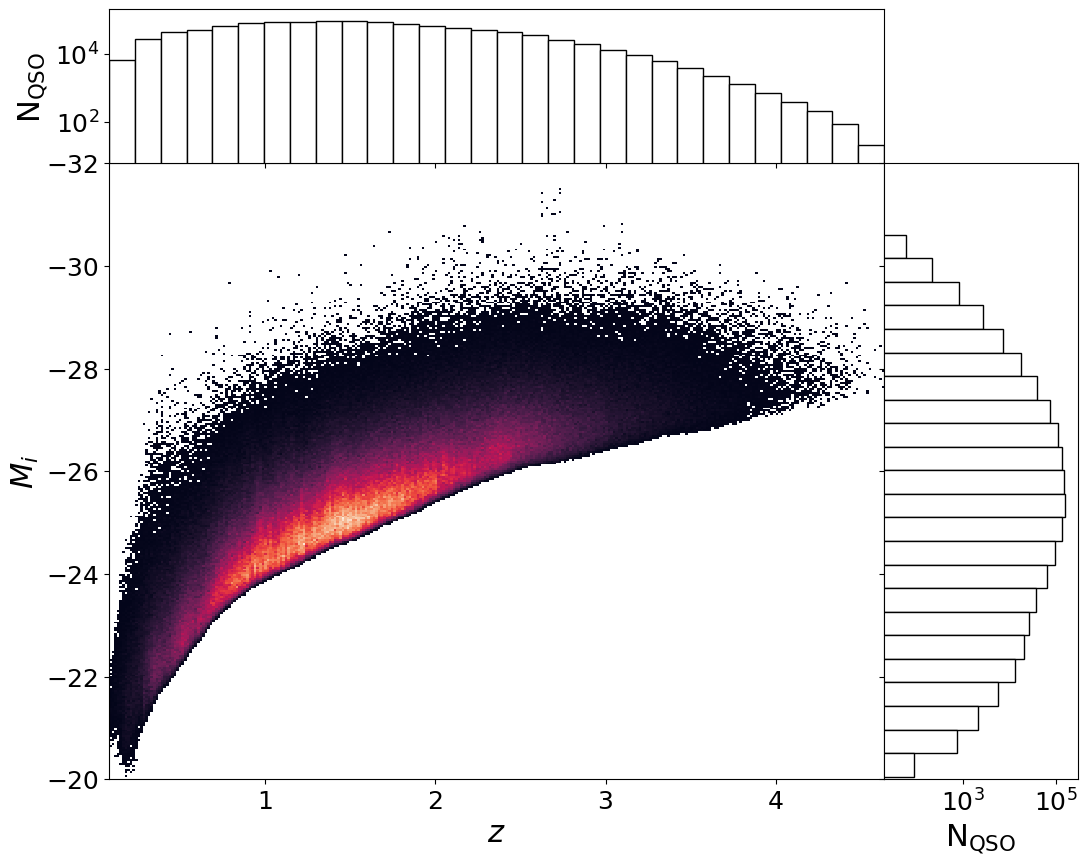

In [11]:
# plot!
fig = plt.figure(figsize = (12.5, 10))
gs = gridspec.GridSpec(2, 2, hspace = 0, height_ratios=[1,4], width_ratios=[4,1], wspace = 0)

ax1 = fig.add_subplot(gs[2])

quaia.absolute(tab_datahi, G_hi)
h1, xedges, yedges, image = ax1.hist2d(tab_datahi['redshift_quaia'][mask_datahi], tab_datahi['M_i'][mask_datahi], cmap = cmap, bins = 300, 
                                       cmin = 1)
ax1.set_ylabel('$M_i$')
ax1.set_xlabel('$z$')
ax1.set_ylim(-20, -32)
xlim = ax1.get_xlim()
ylim = ax1.get_ylim()

ax2 = fig.add_subplot(gs[0])
ax2.hist(tab_datahi['redshift_quaia'][mask_datahi], color = 'white', edgecolor = 'black', bins = 30)
ax2.set_ylabel('N$_\mathrm{QSO}$')
ax2.set_yscale('log')
ax2.set_xlim(xlim)
ax2.set_ylim(6,2e5)
ax2.set_xticklabels([])

ax3 = fig.add_subplot(gs[3])
ax3.hist(tab_datahi['M_i'][mask_datahi], color = 'white', edgecolor = 'black', orientation = 'horizontal', bins = 25)
ax3.set_xlabel('N$_\mathrm{QSO}$')
ax3.set_xscale('log')
ax3.set_yticklabels([])
ax3.set_ylim(ylim)
ax3.set_xlim(2e1,3e5)

plt.show()

# Compute clustering in four z bins
## $w_p(r_p)$

In [12]:
# Create the bins array
rmin = 1 # 30 #0.1
rmax = 200 # 80 #180.0
nbins = 14 # 20 
rbins = np.logspace(np.log10(rmin), np.log10(rmax), nbins + 1) # Mpc/h https://github.com/manodeep/Corrfunc/issues/202
scale = 'log' # 'linear'

# # Create the bins array
# rmin = 30 #0.1
# rmax = 80 #180.0
# nbins = 20 
# rbins = np.linspace(rmin, rmax, nbins + 1) # Mpc/h https://github.com/manodeep/Corrfunc/issues/202
# scale = 'linear'

In [13]:
pimax = 100 # 80 # 40 # 5000.0 # 40.0
# pimax = 80 # 40 # 5000.0 # 40.0

In [14]:
zbin_array = [0.0,1.0,2.0,3.0,4.0]
cmap_blue = plt.get_cmap('Blues')(np.linspace(0.333, 0.999, len(zbin_array)-1))

<>:40: SyntaxWarning: invalid escape sequence '\l'
<>:51: SyntaxWarning: invalid escape sequence '\m'
<>:40: SyntaxWarning: invalid escape sequence '\l'
<>:51: SyntaxWarning: invalid escape sequence '\m'
/tmp/ipykernel_250383/2944247502.py:40: SyntaxWarning: invalid escape sequence '\l'
  ax1.hist(tab_datahi_mask_zbin0['redshift_quaia'], label = '${:.0f}<z \leq{:.0f}$'.format(zbin, zbin+1),
/tmp/ipykernel_250383/2944247502.py:51: SyntaxWarning: invalid escape sequence '\m'
  ax1.set_ylabel('$N_\mathrm{QSO}$')


G20.5_zmin0.0zmax1.0: 0.00              324336 vs 324336


[Warning] The CPU supports AVX512F but the compiler does not.  Can you try another compiler?
/home/groups/tabel/mahlet/pyccl-env/lib/python3.12/site-packages/Corrfunc/utils.py:918: UserWarning: One or more input array has non-native endianness!  A copy will be made with the correct endianness.
  warnings.warn("One or more input array has non-native endianness!  A copy will"\


G20.5_zmin1.0zmax2.0: 0.00              648196 vs 648196


/home/groups/tabel/mahlet/pyccl-env/lib/python3.12/site-packages/Corrfunc/utils.py:918: UserWarning: One or more input array has non-native endianness!  A copy will be made with the correct endianness.
  warnings.warn("One or more input array has non-native endianness!  A copy will"\


G20.5_zmin2.0zmax3.0: 0.00              286508 vs 286508


/home/groups/tabel/mahlet/pyccl-env/lib/python3.12/site-packages/Corrfunc/utils.py:918: UserWarning: One or more input array has non-native endianness!  A copy will be made with the correct endianness.
  warnings.warn("One or more input array has non-native endianness!  A copy will"\


G20.5_zmin3.0zmax4.0: 0.23              27584 vs 35630


/home/groups/tabel/mahlet/pyccl-env/lib/python3.12/site-packages/Corrfunc/utils.py:918: UserWarning: One or more input array has non-native endianness!  A copy will be made with the correct endianness.
  warnings.warn("One or more input array has non-native endianness!  A copy will"\


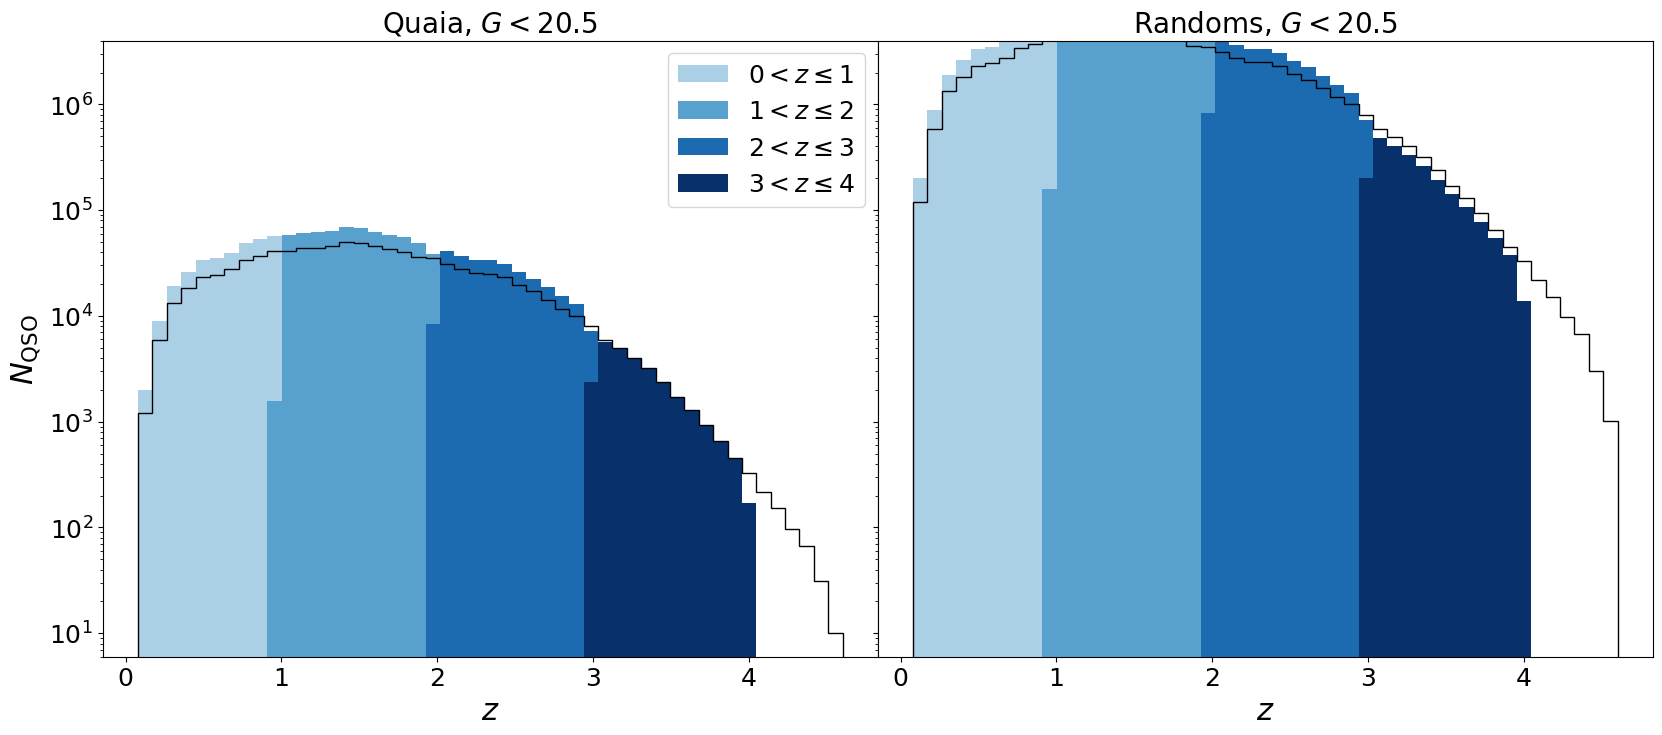

In [15]:
# plot data
bins = np.linspace(0.08, 4.6)
wp, rpavg = [], []
fac_rand = 100 # 25
mask = 0.5
fn_selhi = '../data/maps/selection_function_NSIDE64_G{}.fits'.format(G_hi)
selfunc_hi = hp.fitsfunc.read_map(fn_selhi)
b = [0, 0, 0, 30]

fn_datahi = '../data/quaia_G{}.fits'.format(G_hi)
tab_datahi = Table.read(fn_datahi)
pixel_indices_datahi = hp.ang2pix(NSIDE, tab_datahi['ra'], tab_datahi['dec'], lonlat=True)
mask_datahi = selfunc_hi[pixel_indices_datahi]>=np.percentile(selfunc_hi, mask*100)

# plot!
fig = plt.figure(figsize = (20, 8))
gs = gridspec.GridSpec(1, 2, wspace = 0)

ax1 = fig.add_subplot(gs[0])
ax1.hist(tab_datahi['redshift_quaia'][mask_datahi], bins=bins, histtype = 'step', color='black')

# plot randoms  
ax2 = fig.add_subplot(gs[1])

# for comparison purposes
fn_randhi = '../data/randoms/random_G{}_{}x.fits'.format(G_hi, fac_rand)
tab_randhi = Table.read(fn_randhi)
pixel_indices_randhi = hp.ang2pix(NSIDE, tab_randhi['ra'], tab_randhi['dec'], lonlat=True)
mask_randhi = selfunc_hi[pixel_indices_randhi]>=np.percentile(selfunc_hi, mask*100)
N_randhi_mask = len(tab_randhi['ra'][mask_randhi])
N_datahi_mask = len(tab_datahi['ra'][mask_datahi])
quaia.z_dist(tab_datahi, tab_randhi, mask_datahi, mask_randhi, N_datahi_mask, N_randhi_mask, mask_type = mask_type)
ax2.hist(tab_randhi['redshift_quaia_'+mask_type], histtype = 'step', bins = bins, 
         color = 'black')

for zbin in zbin_array[:-1]:
    tab_datahi_mask_zbin0, tab_randhi_mask_zbin0, key_zbin0, _, _, _, _= quaia.make_bins(G_hi, int(zbin),True, 'z', bins = zbin_array, 
                                                                                       tab_gcat_type = 'data', method = 'minmax', 
                                                                                    fac_rand = fac_rand, mask_type = 'b', b = b[int(zbin)])
    ax1.hist(tab_datahi_mask_zbin0['redshift_quaia'], label = '${:.0f}<z \leq{:.0f}$'.format(zbin, zbin+1), 
             bins = bins, color = cmap_blue[int(zbin)])
    ax2.hist(tab_randhi_mask_zbin0['redshift_quaia_{}'.format(key_zbin0)], label = 'bin{}'.format(zbin),
             bins = bins, color = cmap_blue[int(zbin)])

    wp_datahi_zbin0, rpavg_datahi_zbin0 = quaia.wp_rp(tab_datahi_mask_zbin0, tab_randhi_mask_zbin0, key_zbin0, nthreads = nthreads, 
                                                                  rbins = rbins, nbins = nbins, pimax = pimax, Om0 = 0.315, h = 0.674)
    wp.append(wp_datahi_zbin0)
    rpavg.append(rpavg_datahi_zbin0)

ax1.set_xlabel('$z$')
ax1.set_ylabel('$N_\mathrm{QSO}$')
ax1.set_yscale('log')
ax1.set_ylim(6,4e6)
ax1.set_title('Quaia, $G<{}$'.format(G_hi))
ax1.legend()

ax2.set_xlabel('$z$')
ax2.set_yscale('log')
ax2.set_ylim(6,4e6)
ax2.set_title('Randoms, $G<{}$'.format(G_hi))
ax2.set_yticklabels([])
plt.show()

## Sanity check

<>:40: SyntaxWarning: invalid escape sequence '\l'
<>:51: SyntaxWarning: invalid escape sequence '\m'
<>:40: SyntaxWarning: invalid escape sequence '\l'
<>:51: SyntaxWarning: invalid escape sequence '\m'
/tmp/ipykernel_250383/4001869421.py:40: SyntaxWarning: invalid escape sequence '\l'
  ax1.hist(tab_datahi_mask_zbin0['redshift_quaia'], label = '${:.0f}<z \leq{:.0f}$'.format(zbin, zbin+1),
/tmp/ipykernel_250383/4001869421.py:51: SyntaxWarning: invalid escape sequence '\m'
  ax1.set_ylabel('$N_\mathrm{QSO}$')


../data/maps/selection_function_NSIDE64_G20.5_zmin0.0zmax1.0.fits
../data/randoms/random_G20.5_zmin0.0zmax1.0_100x.fits
G20.5_zmin0.0zmax1.0: 0.00              324336 vs 324336
99.96642370874649


/home/groups/tabel/mahlet/pyccl-env/lib/python3.12/site-packages/Corrfunc/utils.py:918: UserWarning: One or more input array has non-native endianness!  A copy will be made with the correct endianness.
  warnings.warn("One or more input array has non-native endianness!  A copy will"\


../data/maps/selection_function_NSIDE64_G20.5_zmin1.0zmax2.0.fits
../data/randoms/random_G20.5_zmin1.0zmax2.0_100x.fits
G20.5_zmin1.0zmax2.0: 0.00              648196 vs 648196
99.99988429425667


/home/groups/tabel/mahlet/pyccl-env/lib/python3.12/site-packages/Corrfunc/utils.py:918: UserWarning: One or more input array has non-native endianness!  A copy will be made with the correct endianness.
  warnings.warn("One or more input array has non-native endianness!  A copy will"\


../data/maps/selection_function_NSIDE64_G20.5_zmin2.0zmax3.0.fits
../data/randoms/random_G20.5_zmin2.0zmax3.0_100x.fits
G20.5_zmin2.0zmax3.0: 0.00              286508 vs 286508
99.85823432504502


/home/groups/tabel/mahlet/pyccl-env/lib/python3.12/site-packages/Corrfunc/utils.py:918: UserWarning: One or more input array has non-native endianness!  A copy will be made with the correct endianness.
  warnings.warn("One or more input array has non-native endianness!  A copy will"\


../data/maps/selection_function_NSIDE64_G20.5_zmin3.0zmax4.0.fits
../data/randoms/random_G20.5_zmin3.0zmax4.0_100x.fits
G20.5_zmin3.0zmax4.0: 0.23              27584 vs 35630
83.66955481438515


/home/groups/tabel/mahlet/pyccl-env/lib/python3.12/site-packages/Corrfunc/utils.py:918: UserWarning: One or more input array has non-native endianness!  A copy will be made with the correct endianness.
  warnings.warn("One or more input array has non-native endianness!  A copy will"\


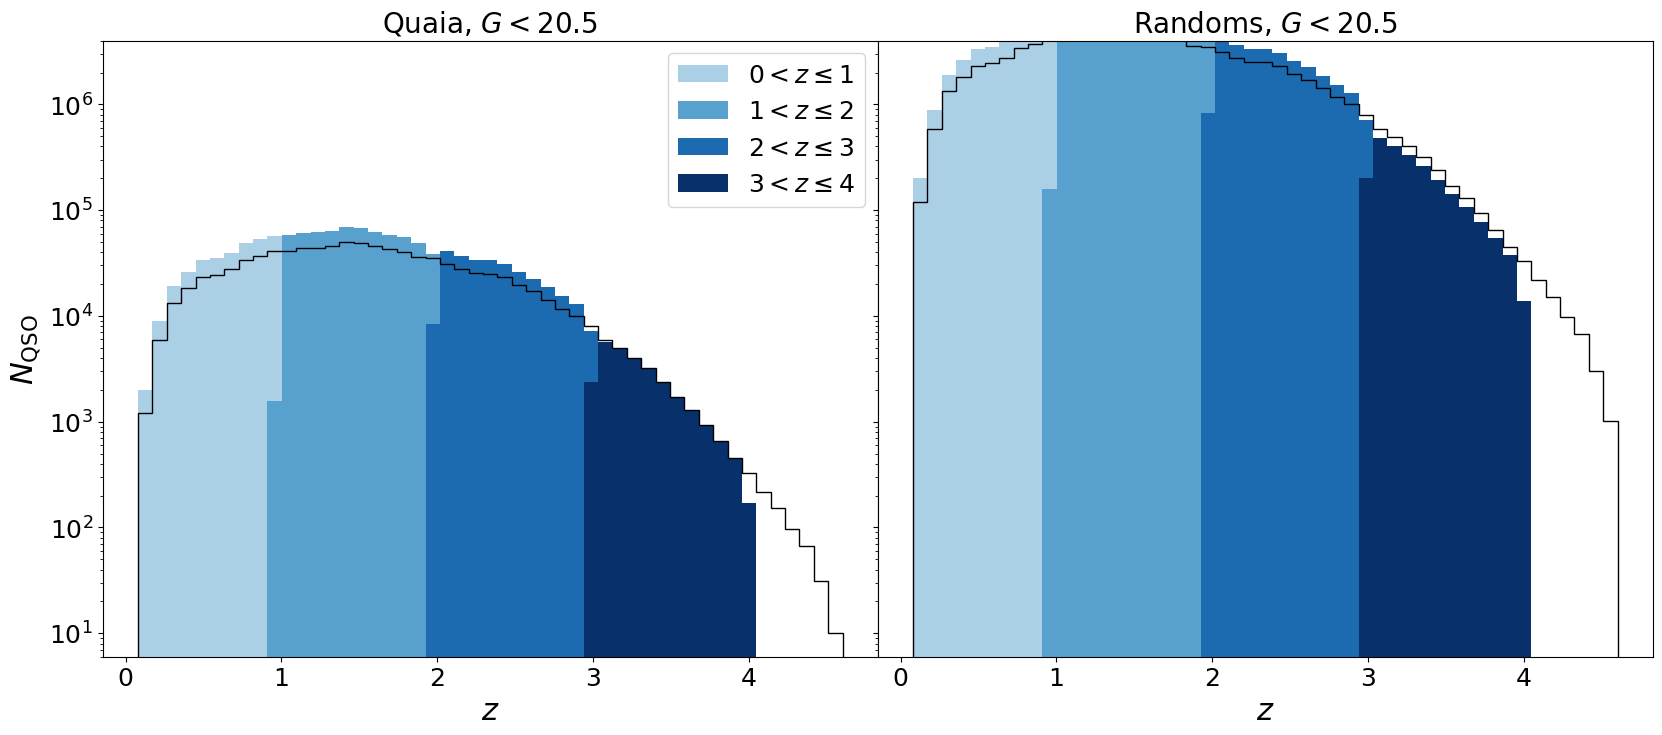

In [16]:
# plot data
bins = np.linspace(0.08, 4.6)
wp_debug, rpavg_debug = [], []
fac_rand = 100 # 25
mask = 0.5
fn_selhi = '../data/maps/selection_function_NSIDE64_G{}.fits'.format(G_hi)
selfunc_hi = hp.fitsfunc.read_map(fn_selhi)
b = [0, 0, 0, 30]

fn_datahi = '../data/quaia_G{}.fits'.format(G_hi)
tab_datahi = Table.read(fn_datahi)
pixel_indices_datahi = hp.ang2pix(NSIDE, tab_datahi['ra'], tab_datahi['dec'], lonlat=True)
mask_datahi = selfunc_hi[pixel_indices_datahi]>=np.percentile(selfunc_hi, mask*100)

# plot!
fig = plt.figure(figsize = (20, 8))
gs = gridspec.GridSpec(1, 2, wspace = 0)

ax1 = fig.add_subplot(gs[0])
ax1.hist(tab_datahi['redshift_quaia'][mask_datahi], bins=bins, histtype = 'step', color='black')

# plot randoms  
ax2 = fig.add_subplot(gs[1])

# for comparison purposes
fn_randhi = '../data/randoms/random_G{}_{}x.fits'.format(G_hi, fac_rand)
tab_randhi = Table.read(fn_randhi)
pixel_indices_randhi = hp.ang2pix(NSIDE, tab_randhi['ra'], tab_randhi['dec'], lonlat=True)
mask_randhi = selfunc_hi[pixel_indices_randhi]>=np.percentile(selfunc_hi, mask*100)
N_randhi_mask = len(tab_randhi['ra'][mask_randhi])
N_datahi_mask = len(tab_datahi['ra'][mask_datahi])
quaia.z_dist(tab_datahi, tab_randhi, mask_datahi, mask_randhi, N_datahi_mask, N_randhi_mask, mask_type = mask_type)
ax2.hist(tab_randhi['redshift_quaia_'+mask_type], histtype = 'step', bins = bins, 
         color = 'black')

for zbin in zbin_array[:-1]:
    tab_datahi_mask_zbin0, tab_randhi_mask_zbin0, key_zbin0, _, _, _, _, _, _, _, _ = quaia_debug.make_bins(G_hi, int(zbin),True, 'z', bins = zbin_array, 
                                                                                       tab_gcat_type = 'data', method = 'minmax', 
                                                                                    fac_rand = fac_rand, mask_type = 'b', b = b[int(zbin)])
    ax1.hist(tab_datahi_mask_zbin0['redshift_quaia'], label = '${:.0f}<z \leq{:.0f}$'.format(zbin, zbin+1), 
             bins = bins, color = cmap_blue[int(zbin)])
    ax2.hist(tab_randhi_mask_zbin0['redshift_quaia_{}'.format(key_zbin0)], label = 'bin{}'.format(zbin),
             bins = bins, color = cmap_blue[int(zbin)])

    wp_datahi_zbin0, rpavg_datahi_zbin0 = quaia_debug.wp_rp(tab_datahi_mask_zbin0, tab_randhi_mask_zbin0, key_zbin0, nthreads = nthreads, 
                                                                  rbins = rbins, nbins = nbins, pimax = pimax, Om0 = 0.315, h = 0.674, units = 'Mpc*h')
    wp_debug.append(wp_datahi_zbin0)
    rpavg_debug.append(rpavg_datahi_zbin0)

ax1.set_xlabel('$z$')
ax1.set_ylabel('$N_\mathrm{QSO}$')
ax1.set_yscale('log')
ax1.set_ylim(6,4e6)
ax1.set_title('Quaia, $G<{}$'.format(G_hi))
ax1.legend()

ax2.set_xlabel('$z$')
ax2.set_yscale('log')
ax2.set_ylim(6,4e6)
ax2.set_title('Randoms, $G<{}$'.format(G_hi))
ax2.set_yticklabels([])
plt.show()

# Use delete-one jackknife resampling
## Split the sky into ten RA stripes

In [20]:
ra_bins = np.linspace(0, 360, 11)
N = len(ra_bins)
for i in range(N-1):
    
    delete = (tab_datahi_mask_zbin0['ra']>=ra_bins[i+1]) | (tab_datahi_mask_zbin0['ra'] <ra_bins[i])
    print(np.unique(np.digitize(tab_datahi_mask_zbin0['ra'][delete], ra_bins)))

[ 2  3  4  5  6  7  8  9 10]
[ 1  3  4  5  6  7  8  9 10]
[ 1  2  4  5  6  7  8  9 10]
[ 1  2  3  5  6  7  8  9 10]
[ 1  2  3  4  6  7  8  9 10]
[ 1  2  3  4  5  7  8  9 10]
[ 1  2  3  4  5  6  8  9 10]
[ 1  2  3  4  5  6  7  9 10]
[ 1  2  3  4  5  6  7  8 10]
[1 2 3 4 5 6 7 8 9]


## Compute $w_p(r_p)$ in each jackknife bin

In [23]:
wp_jackknife, rpavg_jackknife = {zbin: [] for zbin in zbin_array[:-1]}, {zbin: [] for zbin in zbin_array[:-1]}
for zbin in zbin_array[:-1]:
    
    tab_datahi_mask_zbin0, tab_randhi_mask_zbin0, key_zbin0, _, _, _, _= quaia.make_bins(G_hi, int(zbin),True, 'z', bins = zbin_array, 
                                                                                       tab_gcat_type = 'data', method = 'minmax', 
                                                                                    fac_rand = fac_rand, mask_type = 'b', b = b[int(zbin)])

    for i in trange(len(ra_bins)-1):
    
        jackknife_data = (tab_datahi_mask_zbin0['ra'] >= ra_bins[i+1]) | (tab_datahi_mask_zbin0['ra'] < ra_bins[i])
        jackknife_rand = (tab_randhi_mask_zbin0['ra'] >= ra_bins[i+1]) | (tab_randhi_mask_zbin0['ra'] < ra_bins[i])

        wp_datahi_zbin0, rpavg_datahi_zbin0 = quaia_debug.wp_rp(tab_datahi_mask_zbin0[jackknife_data], tab_randhi_mask_zbin0[jackknife_rand], 
                                                                key_zbin0, nthreads = nthreads, rbins = rbins, nbins = nbins, pimax = pimax,
                                                                Om0 = 0.315, h = 0.674, 
                                                          units = 'Mpc*h')
        wp_jackknife[zbin].append(wp_datahi_zbin0)
        rpavg_jackknife[zbin].append(rpavg_datahi_zbin0)

G20.5_zmin0.0zmax1.0: 0.00              324336 vs 324336


  0%|          | 0/10 [00:00<?, ?it/s]/home/groups/tabel/mahlet/pyccl-env/lib/python3.12/site-packages/Corrfunc/utils.py:918: UserWarning: One or more input array has non-native endianness!  A copy will be made with the correct endianness.
  warnings.warn("One or more input array has non-native endianness!  A copy will"\
100%|██████████| 10/10 [35:56<00:00, 215.68s/it]


G20.5_zmin1.0zmax2.0: 0.00              648196 vs 648196


  0%|          | 0/10 [00:00<?, ?it/s]/home/groups/tabel/mahlet/pyccl-env/lib/python3.12/site-packages/Corrfunc/utils.py:918: UserWarning: One or more input array has non-native endianness!  A copy will be made with the correct endianness.
  warnings.warn("One or more input array has non-native endianness!  A copy will"\
100%|██████████| 10/10 [58:58<00:00, 353.81s/it] 


G20.5_zmin2.0zmax3.0: 0.00              286508 vs 286508


  0%|          | 0/10 [00:00<?, ?it/s]/home/groups/tabel/mahlet/pyccl-env/lib/python3.12/site-packages/Corrfunc/utils.py:918: UserWarning: One or more input array has non-native endianness!  A copy will be made with the correct endianness.
  warnings.warn("One or more input array has non-native endianness!  A copy will"\
100%|██████████| 10/10 [21:38<00:00, 129.81s/it]


G20.5_zmin3.0zmax4.0: 0.23              27584 vs 35630


  0%|          | 0/10 [00:00<?, ?it/s]/home/groups/tabel/mahlet/pyccl-env/lib/python3.12/site-packages/Corrfunc/utils.py:918: UserWarning: One or more input array has non-native endianness!  A copy will be made with the correct endianness.
  warnings.warn("One or more input array has non-native endianness!  A copy will"\
100%|██████████| 10/10 [01:51<00:00, 11.18s/it]


## Compute the jackknife covariance matrix
### \begin{array}{r}
C_{i j}=\frac{N-1}{N} \sum_{k=1}^N\left[\xi^{(k)}\left(s_{i}\right)-\bar{\xi}\left(s_{i}\right)\right] \\
{\left[\xi^{(k)}\left(s_{j}\right)-\bar{\xi}\left(s_{j}\right)\right]}
\end{array}

In [24]:
C = {zbin: [] for zbin in zbin_array[:-1]}
for zbin in zbin_array[:-1]:
    
    wp_mean = np.nanmean(wp_jackknife[zbin], axis = 0)  # is it ok to ignore nan values?
    delta = wp_jackknife[zbin]-wp_mean
    C[zbin] = (N-1)/N*(delta.T @ delta)

## Save the diagonal elements
### $\sigma_{\xi}\left(s_{i}\right)=\sqrt{C_{i i}}$

In [44]:
# for zbin in zbin_array[:-1]:
    
#     np.save('../results/sigma_wp_G{}_rmin{}_rmax{}_nbins{}_pimax{}_z{}_b'.format(G_hi, rmin, rmax, nbins, pimax, zbin), np.sqrt(np.diag(C[zbin])))

## Save the full covariance

In [25]:
for zbin in zbin_array[:-1]:
    
    np.save('../results/cov_wp_G{}_rmin{}_rmax{}_nbins{}_pimax{}_z{}_b_planck20_{}x_times_h'.format(G_hi, rmin, rmax, nbins, pimax, zbin, fac_rand), 
            C[zbin])

# Plot

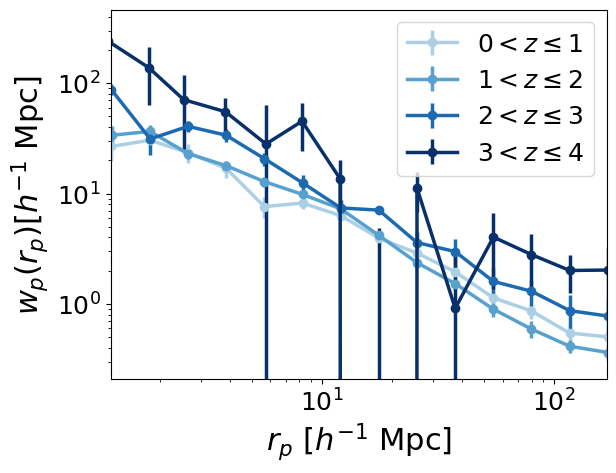

In [22]:
# plot!
r = quaia.recenter(rbins)
for zbin in zbin_array[:-1]:
    sigma = np.sqrt(np.diag(np.load('../results/cov_wp_G{}_rmin{}_rmax{}_nbins{}_pimax{}_z{}_b_planck20_{}x.npy'.format(G_hi, rmin, rmax, nbins, pimax, zbin, fac_rand))))
    plt.errorbar(rpavg[int(zbin)], wp[int(zbin)], marker = 'o', label = '${:.0f}<z \leq{:.0f}$'.format(zbin, zbin+1), 
             linewidth = 2.5, color = cmap_blue[int(zbin)], yerr = sigma) # np.sqrt(np.diag(C[zbin])))
    plt.xlabel(r'$r_p$ $[h^{-1}$ Mpc]') # projected
    if scale == 'log':
        plt.xscale('log')
    plt.yscale('log')
    plt.xlim(r[0], r[-1])
    plt.legend()
    plt.ylabel(r"$w_p(r_p) [h^{-1}$ Mpc]")
plt.show()

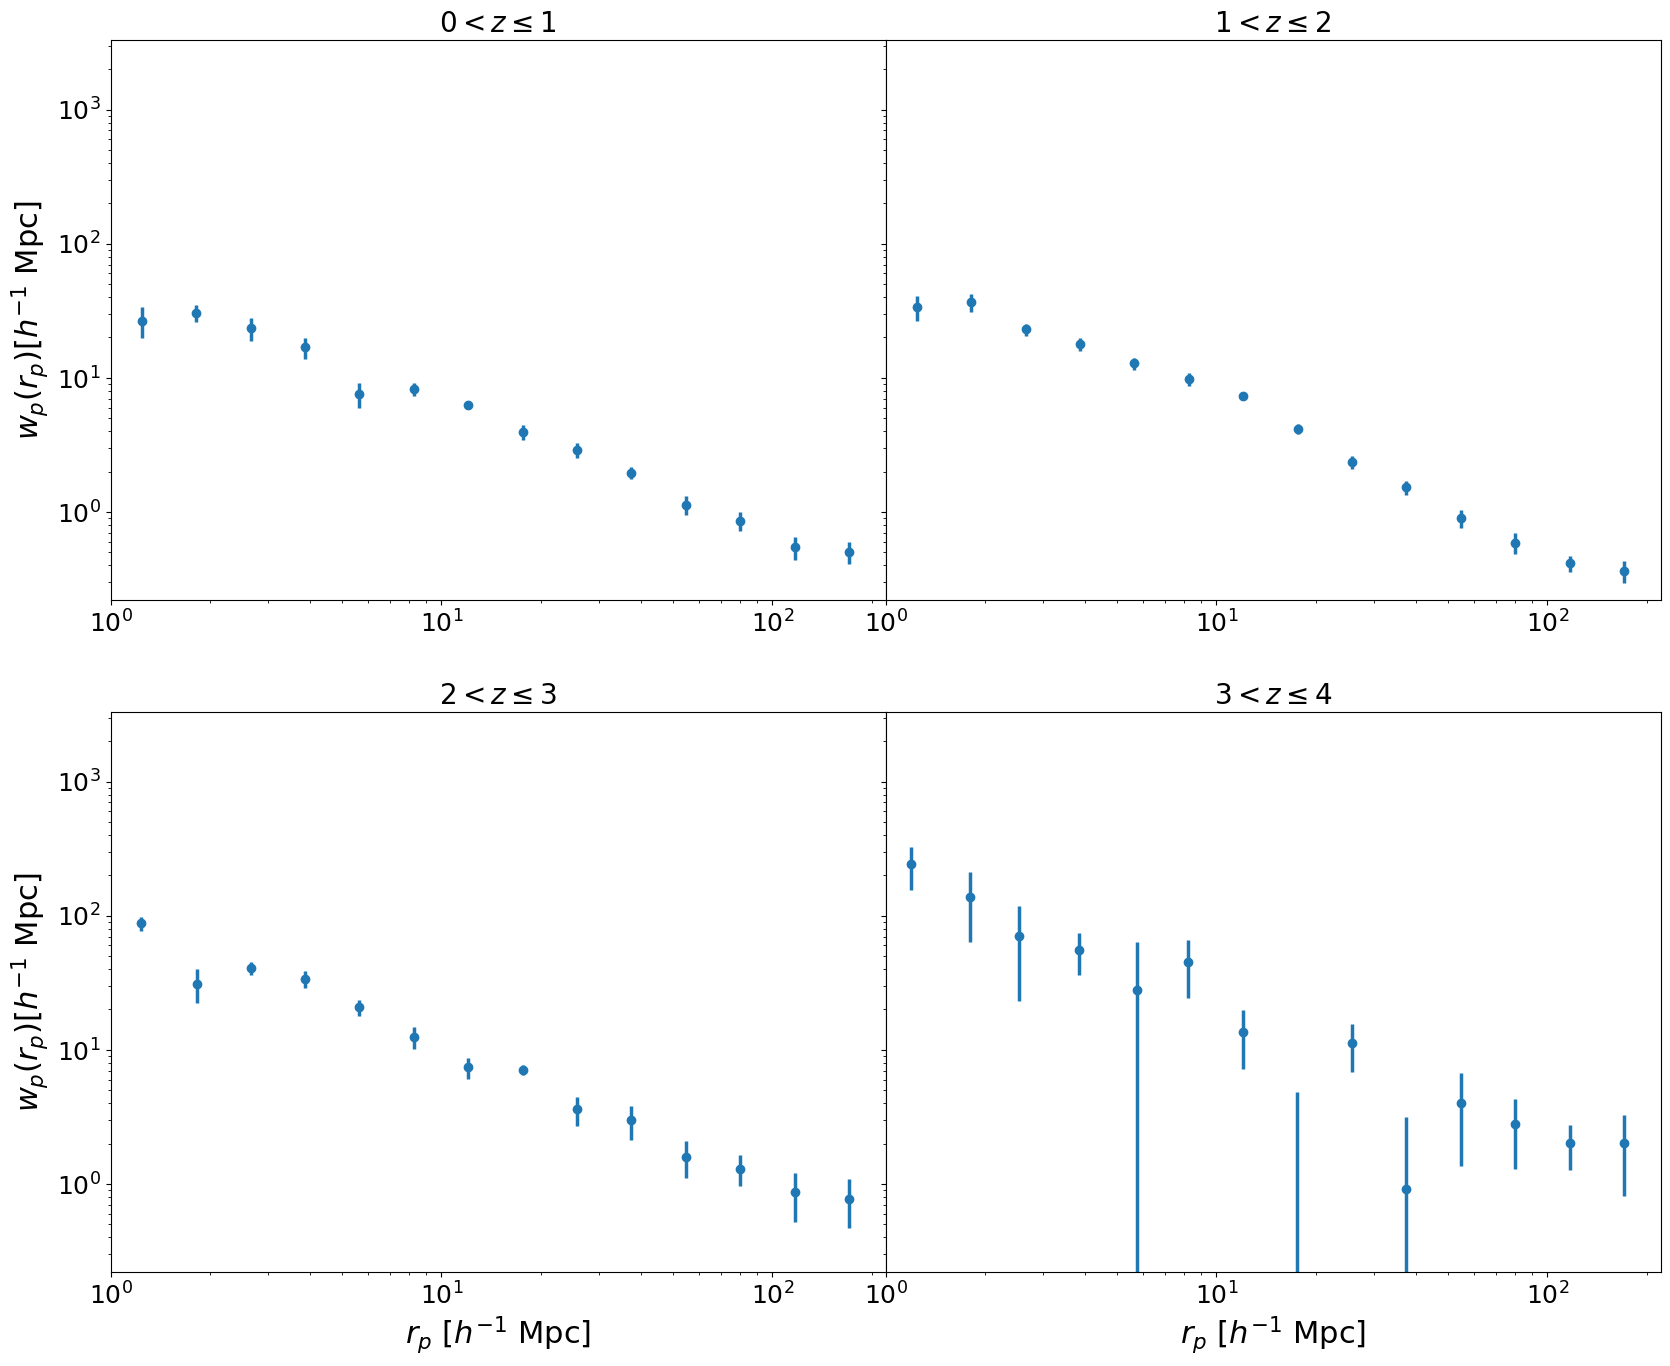

In [23]:
# plot!
fig = plt.figure(figsize = (20, 16))
gs = gridspec.GridSpec(2, 2, wspace = 0, hspace = 0.2)
ymin, ymax = [], []
ax=[]
for zbin in zbin_array[:-1]:
    
    ax1 = fig.add_subplot(gs[int(zbin)])
    ax.append(ax1)
        
    sigma = np.sqrt(np.diag(np.load('../results/cov_wp_G{}_rmin{}_rmax{}_nbins{}_pimax{}_z{}_b_planck20_{}x.npy'.format(G_hi, rmin, rmax, nbins, pimax, zbin, fac_rand))))
    ax1.errorbar(rpavg[int(zbin)], wp[int(zbin)], marker = 'o', label = '${:.0f}<z \leq{:.0f}$'.format(zbin, zbin+1), 
             linewidth = 2.5, yerr = sigma, linestyle = 'None')
    ax1.set_title('${:.0f}<z \leq{:.0f}$'.format(zbin, zbin+1))
    if scale == 'log':
        ax1.set_xscale('log')
    ax1.set_yscale('log')
    ax1.set_xlim(rmin, 2.2e2)
    ax1.set_ylim(2.2e-1, 3.3e3)
    # ax1.set_ylim(2.25e-1, 3.25e3)
    if zbin>1:
        ax1.set_xlabel(r'$r_p$ $[h^{-1}$ Mpc]') # projected
    if zbin%2==0:
        ax1.set_ylabel(r"$w_p(r_p) [h^{-1}$ Mpc]")
    else:
        ax1.set_yticklabels([])

plt.show()

## Sanity check

<>:16: SyntaxWarning: invalid escape sequence '\l'
<>:16: SyntaxWarning: invalid escape sequence '\l'
/tmp/ipykernel_252278/87902524.py:16: SyntaxWarning: invalid escape sequence '\l'
  ax1.set_title('${:.0f}<z \leq{:.0f}$'.format(zbin, zbin+1))


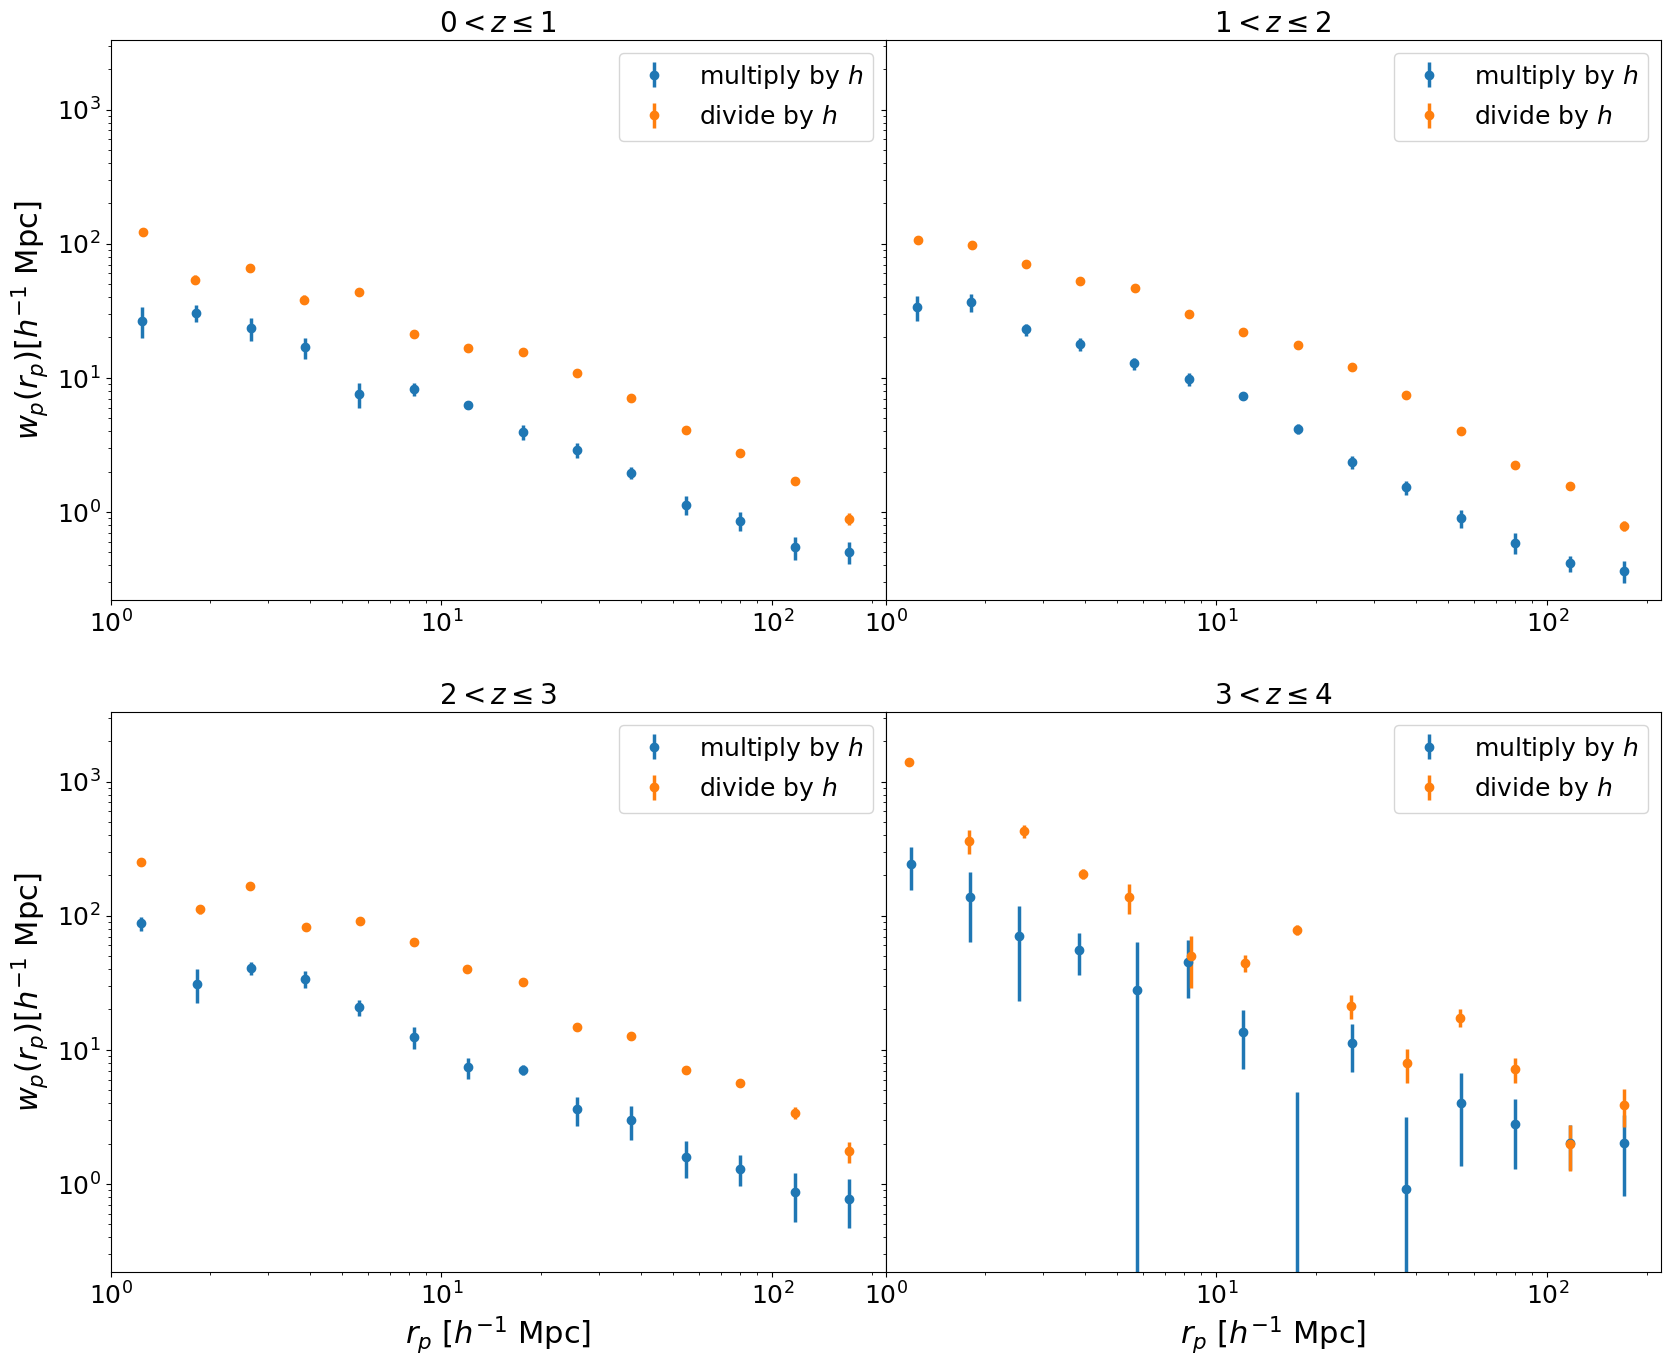

In [23]:
# plot!
fig = plt.figure(figsize = (20, 16))
gs = gridspec.GridSpec(2, 2, wspace = 0, hspace = 0.2)
ymin, ymax = [], []
ax=[]
for zbin in zbin_array[:-1]:
    
    ax1 = fig.add_subplot(gs[int(zbin)])
    ax.append(ax1)
        
    sigma = np.sqrt(np.diag(np.load('../results/cov_wp_G{}_rmin{}_rmax{}_nbins{}_pimax{}_z{}_b_planck20_{}x.npy'.format(G_hi, rmin, rmax, nbins, pimax, zbin, fac_rand))))
    ax1.errorbar(rpavg[int(zbin)], wp[int(zbin)], marker = 'o', label = 'multiply by $h$', 
             linewidth = 2.5, yerr = sigma, linestyle = 'None')
    ax1.errorbar(rpavg_debug[int(zbin)], wp_debug[int(zbin)], marker = 'o', label = 'divide by $h$', 
             linewidth = 2.5, yerr = sigma, linestyle = 'None')
    ax1.set_title('${:.0f}<z \leq{:.0f}$'.format(zbin, zbin+1))
    if scale == 'log':
        ax1.set_xscale('log')
    ax1.set_yscale('log')
    ax1.set_xlim(rmin, 2.2e2)
    ax1.set_ylim(2.2e-1, 3.3e3)
    if zbin>1:
        ax1.set_xlabel(r'$r_p$ $[h^{-1}$ Mpc]') # projected
    if zbin%2==0:
        ax1.set_ylabel(r"$w_p(r_p) [h^{-1}$ Mpc]")
    else:
        ax1.set_yticklabels([])
    ax1.legend()

plt.show()

<>:16: SyntaxWarning: invalid escape sequence '\l'
<>:16: SyntaxWarning: invalid escape sequence '\l'
/tmp/ipykernel_250383/950890146.py:16: SyntaxWarning: invalid escape sequence '\l'
  ax1.set_title('${:.0f}<z \leq{:.0f}$'.format(zbin, zbin+1))


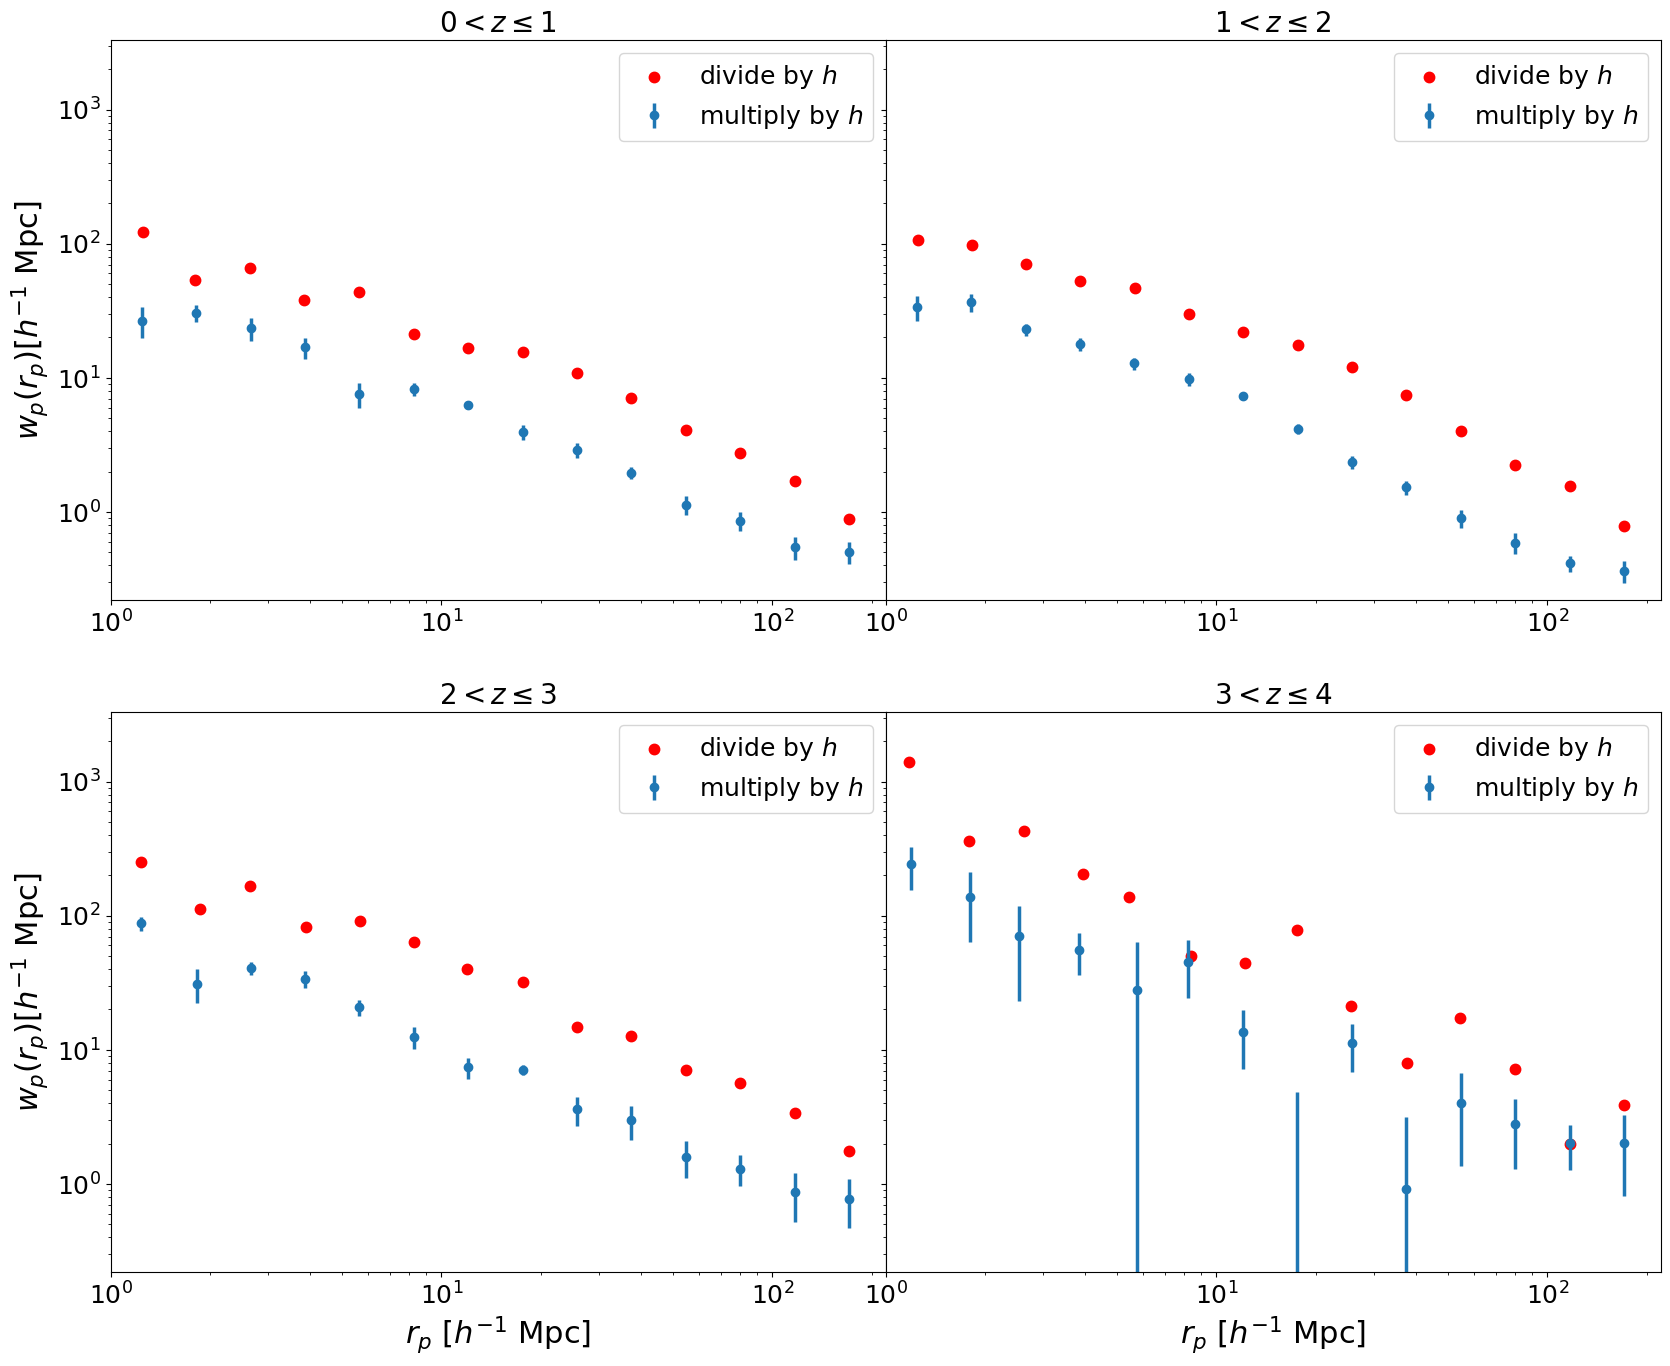

In [19]:
# plot!
fig = plt.figure(figsize = (20, 16))
gs = gridspec.GridSpec(2, 2, wspace = 0, hspace = 0.2)
ymin, ymax = [], []
ax=[]
for zbin in zbin_array[:-1]:
    
    ax1 = fig.add_subplot(gs[int(zbin)])
    ax.append(ax1)
        
    sigma = np.sqrt(np.diag(np.load('../results/cov_wp_G{}_rmin{}_rmax{}_nbins{}_pimax{}_z{}_b_planck20_{}x.npy'.format(G_hi, rmin, rmax, nbins, pimax, zbin, fac_rand))))
    ax1.errorbar(rpavg[int(zbin)], wp[int(zbin)], marker = 'o', label = 'multiply by $h$', 
             linewidth = 2.5, yerr = sigma, linestyle = 'None')
    ax1.scatter(rpavg_debug[int(zbin)], wp_debug[int(zbin)], marker = 'o', label = 'divide by $h$', 
             linewidth = 2.5, linestyle = 'None', color  = 'red')
    ax1.set_title('${:.0f}<z \leq{:.0f}$'.format(zbin, zbin+1))
    if scale == 'log':
        ax1.set_xscale('log')
    ax1.set_yscale('log')
    ax1.set_xlim(rmin, 2.2e2)
    ax1.set_ylim(2.2e-1, 3.3e3)
    if zbin>1:
        ax1.set_xlabel(r'$r_p$ $[h^{-1}$ Mpc]') # projected
    if zbin%2==0:
        ax1.set_ylabel(r"$w_p(r_p) [h^{-1}$ Mpc]")
    else:
        ax1.set_yticklabels([])
    ax1.legend()

plt.show()

<>:20: SyntaxWarning: invalid escape sequence '\l'
<>:20: SyntaxWarning: invalid escape sequence '\l'
/tmp/ipykernel_250383/1423597234.py:20: SyntaxWarning: invalid escape sequence '\l'
  ax1.set_title('${:.0f}<z \leq{:.0f}$'.format(zbin, zbin+1))


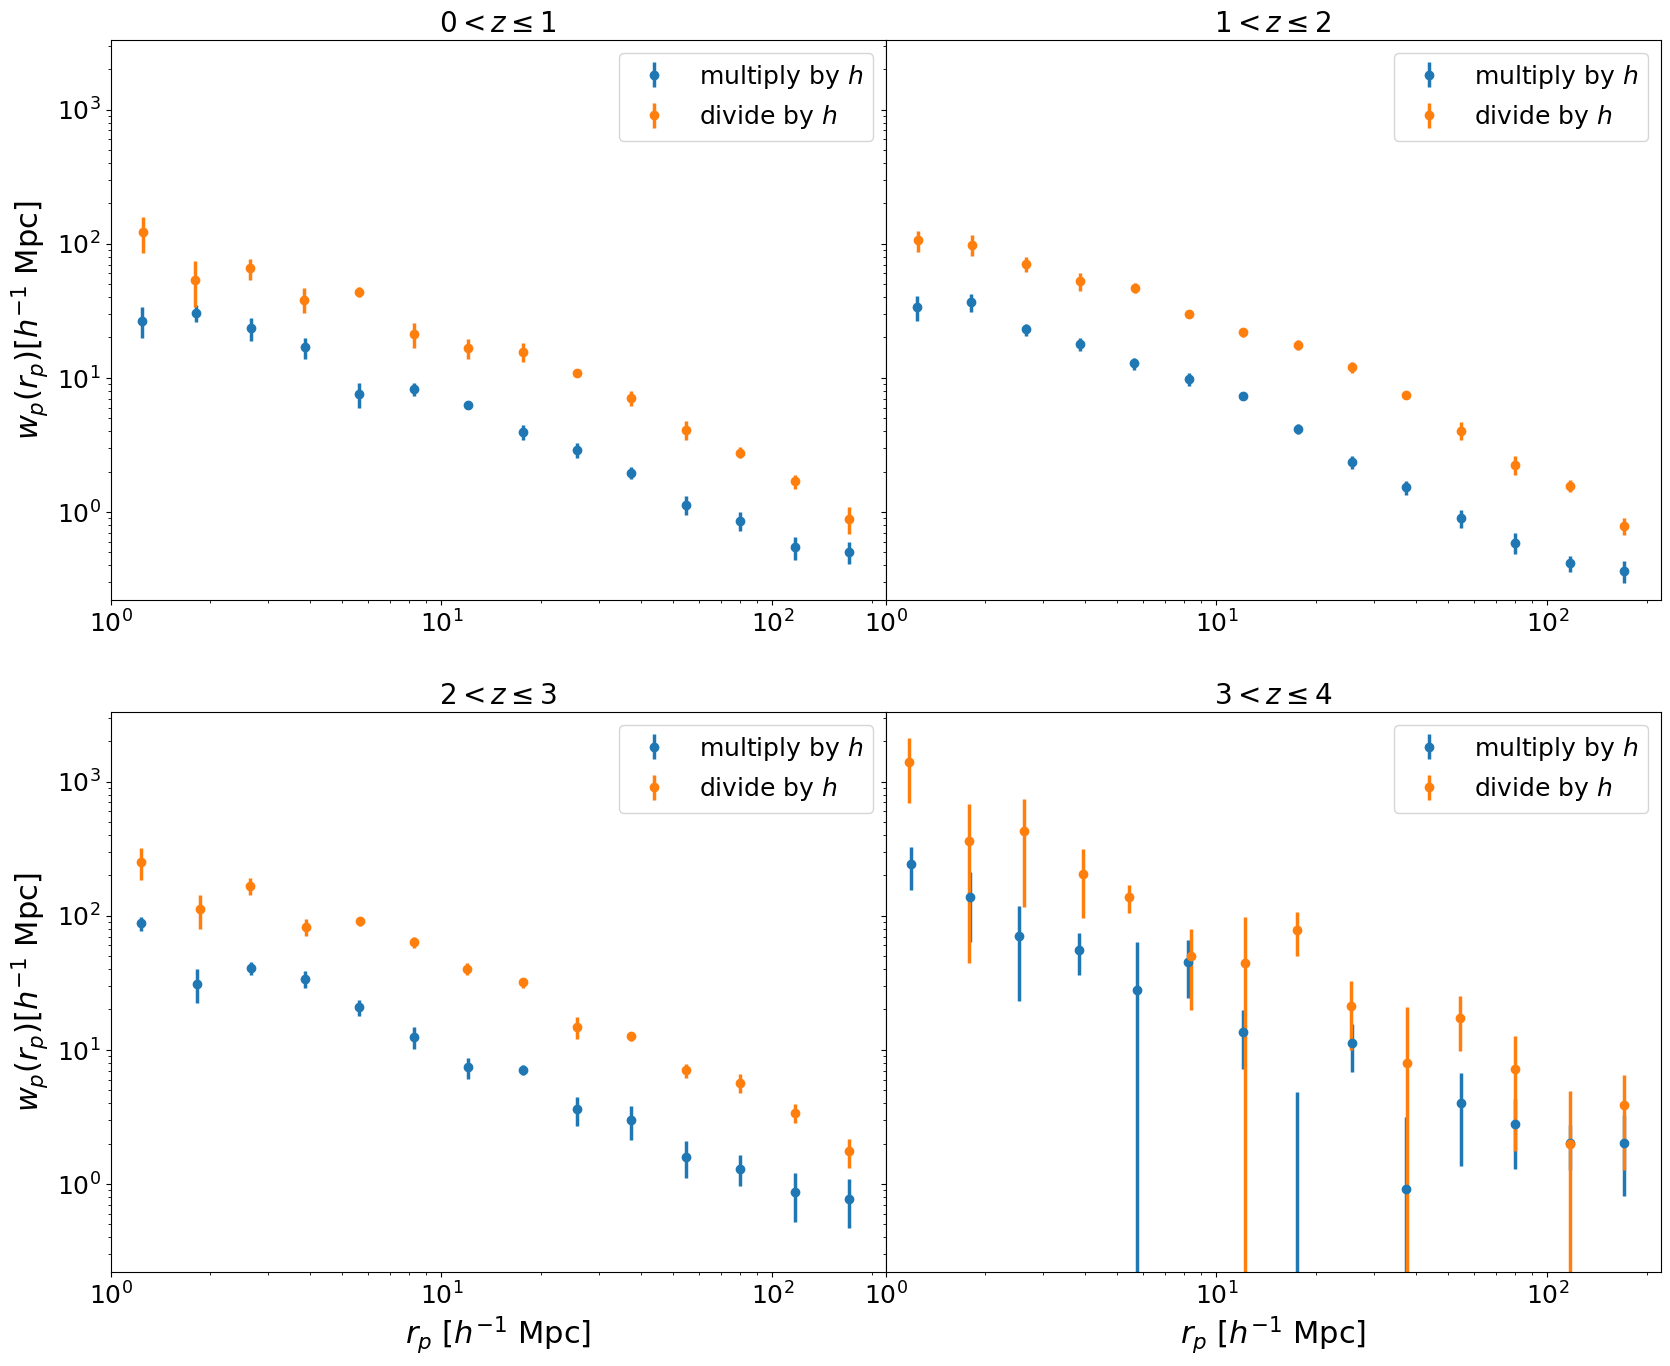

In [26]:
# plot!
fig = plt.figure(figsize = (20, 16))
gs = gridspec.GridSpec(2, 2, wspace = 0, hspace = 0.2)
ymin, ymax = [], []
ax=[]
for zbin in zbin_array[:-1]:
    
    ax1 = fig.add_subplot(gs[int(zbin)])
    ax.append(ax1)
        
    sigma = np.sqrt(np.diag(np.load('../results/cov_wp_G{}_rmin{}_rmax{}_nbins{}_pimax{}_z{}_b_planck20_{}x.npy'.format(G_hi, rmin, rmax, nbins, 
                                                                                                                        pimax, zbin, fac_rand))))
    sigma_h = np.sqrt(np.diag(np.load('../results/cov_wp_G{}_rmin{}_rmax{}_nbins{}_pimax{}_z{}_b_planck20_{}x_times_h.npy'.format(G_hi, rmin, rmax, 
                                                                                                                                  nbins, pimax, zbin, 
                                                                                                                                  fac_rand))))
    ax1.errorbar(rpavg[int(zbin)], wp[int(zbin)], marker = 'o', label = 'multiply by $h$', 
             linewidth = 2.5, yerr = sigma, linestyle = 'None')
    ax1.errorbar(rpavg_debug[int(zbin)], wp_debug[int(zbin)], marker = 'o', label = 'divide by $h$', 
             linewidth = 2.5, yerr = sigma_h, linestyle = 'None')
    ax1.set_title('${:.0f}<z \leq{:.0f}$'.format(zbin, zbin+1))
    if scale == 'log':
        ax1.set_xscale('log')
    ax1.set_yscale('log')
    ax1.set_xlim(rmin, 2.2e2)
    ax1.set_ylim(2.2e-1, 3.3e3)
    if zbin>1:
        ax1.set_xlabel(r'$r_p$ $[h^{-1}$ Mpc]') # projected
    if zbin%2==0:
        ax1.set_ylabel(r"$w_p(r_p) [h^{-1}$ Mpc]")
    else:
        ax1.set_yticklabels([])
    ax1.legend()

plt.show()

## Compare to Shen et al

In [ ]:
# plot!
fig = plt.figure(figsize = (20, 16))
gs = gridspec.GridSpec(2, 2, wspace = 0, hspace = 0.2)
ymin, ymax = [], []
ax=[]
for zbin in zbin_array[:-1]:
    
    ax1 = fig.add_subplot(gs[int(zbin)])
    ax.append(ax1)
        
    sigma = np.sqrt(np.diag(np.load('../results/cov_wp_G{}_rmin{}_rmax{}_nbins{}_pimax{}_z{}_b_planck20_{}x.npy'.format(G_hi, rmin, rmax, nbins, 
                                                                                                                        pimax, zbin, fac_rand))))
    sigma_h = np.sqrt(np.diag(np.load('../results/cov_wp_G{}_rmin{}_rmax{}_nbins{}_pimax{}_z{}_b_planck20_{}x_times_h.npy'.format(G_hi, rmin, rmax, 
                                                                                                                                  nbins, pimax, zbin, 
                                                                                                                                  fac_rand))))
    ax1.errorbar(rpavg[int(zbin)], wp[int(zbin)], marker = 'o', label = 'multiply by $h$', 
             linewidth = 2.5, yerr = sigma, linestyle = 'None')
    ax1.errorbar(rpavg_debug[int(zbin)], wp_debug[int(zbin)], marker = 'o', label = 'divide by $h$', 
             linewidth = 2.5, yerr = sigma_h, linestyle = 'None')
    ax1.set_title('${:.0f}<z \leq{:.0f}$'.format(zbin, zbin+1))
    if scale == 'log':
        ax1.set_xscale('log')
    ax1.set_yscale('log')
    ax1.set_xlim(rmin, 2.2e2)
    ax1.set_ylim(2.2e-1, 3.3e3)
    if zbin>1:
        ax1.set_xlabel(r'$r_p$ $[h^{-1}$ Mpc]') # projected
    if zbin%2==0:
        ax1.set_ylabel(r"$w_p(r_p) [h^{-1}$ Mpc]")
    else:
        ax1.set_yticklabels([])
    ax1.legend()

plt.show()

In [3]:
comoving_r = 2*u.Mpc
H0=70* u.km/u.s/u.Mpc

In [4]:
(comoving_r*cu.littleh).to(u.Mpc, cu.with_H0(H0))/cu.littleh

<Quantity 1.4 Mpc / littleh>

In [9]:
h = (H0/100).value
comoving_r*h/cu.littleh

<Quantity 1.4 Mpc / littleh>

## Plot correlation matrix

(-1.0, 1.0)
(-1.0, 1.0)
(-1.0, 1.0)
(-1.0, 1.0)


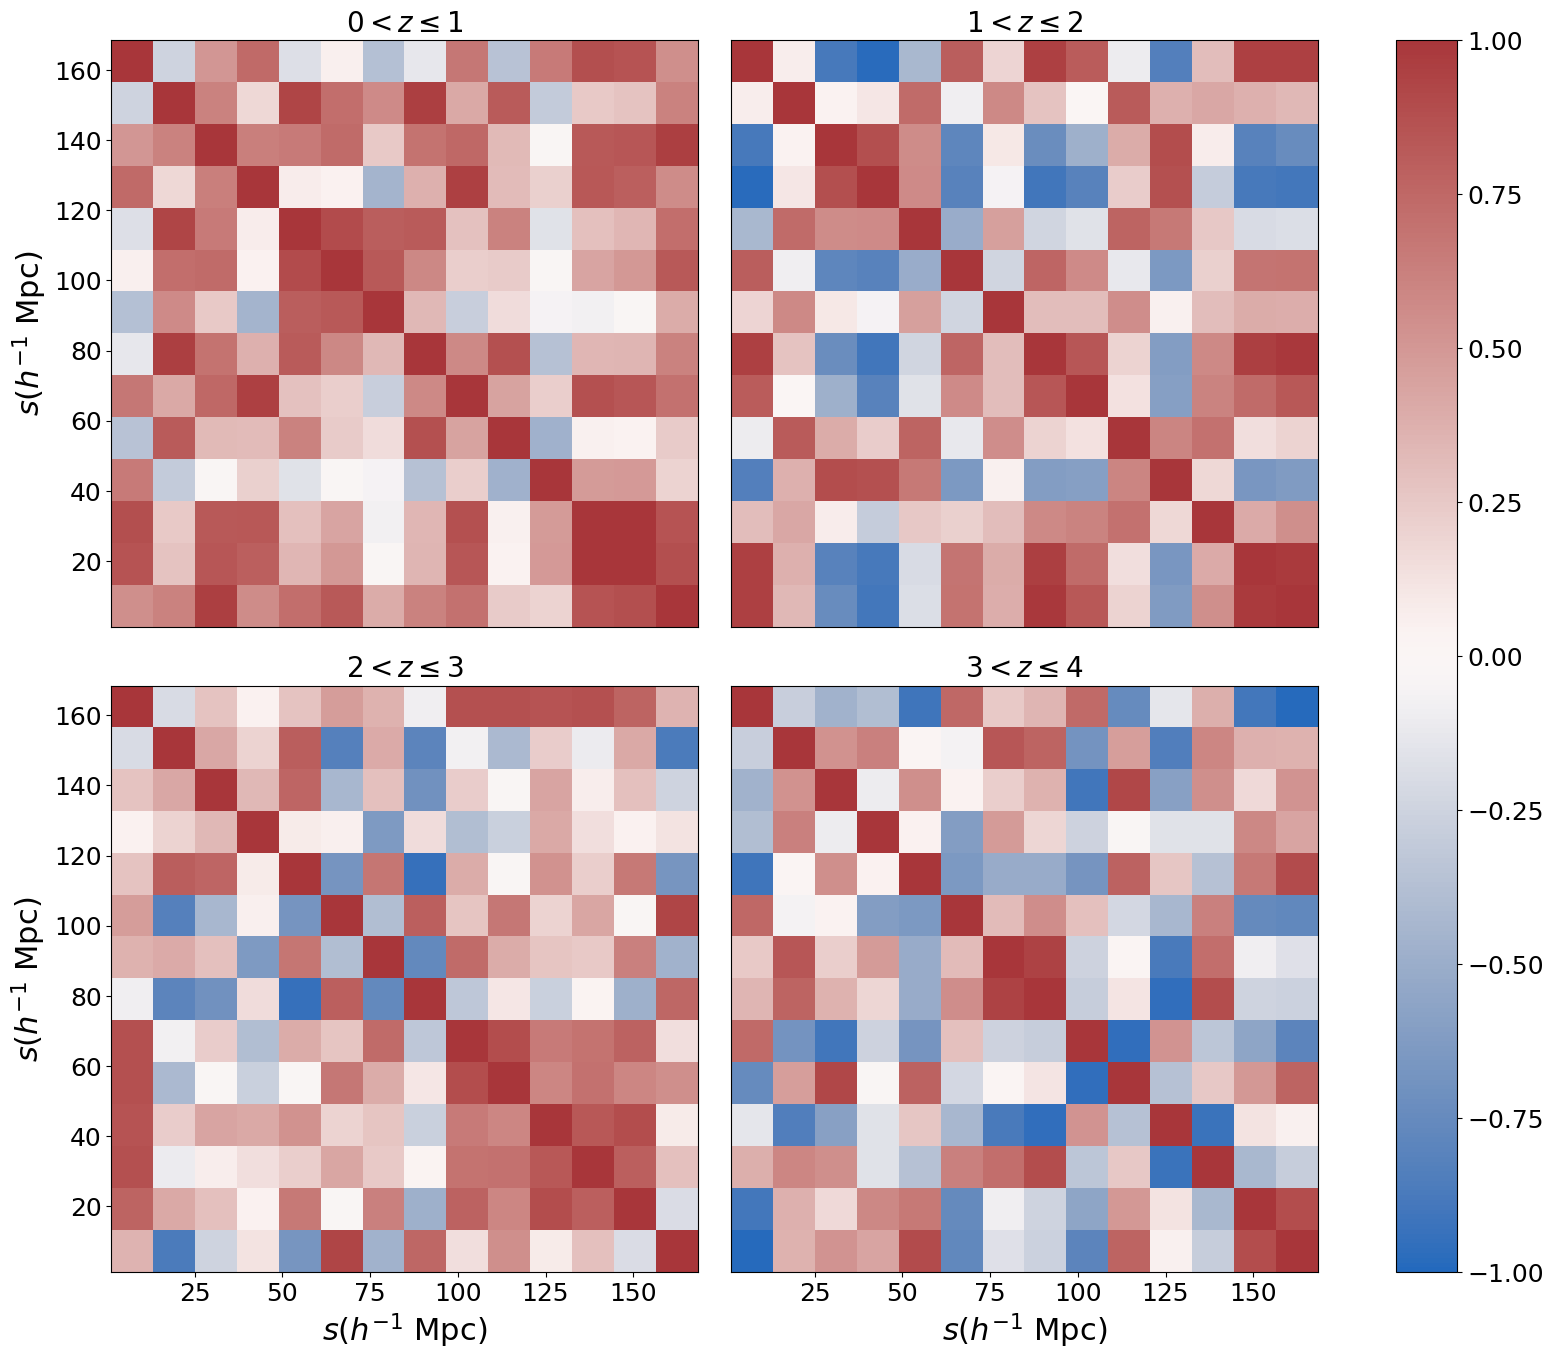

In [41]:
cmap = sns.color_palette("vlag", as_cmap=True)

# plot!
fig = plt.figure(figsize = (20, 16))
gs = gridspec.GridSpec(2, 2, wspace = 0, hspace = 0.1)
axes = []
for zbin in zbin_array[:-1]:
    
    ax1 = fig.add_subplot(gs[int(zbin)])
    
    C = np.load('../results/cov_wp_G{}_rmin{}_rmax{}_nbins{}_pimax{}_z{}_b_planck20_{}x.npy'.format(G_hi, rmin, rmax, nbins, pimax, zbin, fac_rand))
    matrix = np.corrcoef(C)
    image = ax1.imshow(matrix, cmap = cmap, extent = [r[0], r[-1], r[0], r[-1]], vmin = -1, vmax = 1)
    print(image.get_clim())
    if zbin>1:
        ax1.set_xlabel('$s (h^{-1}$ Mpc)')
    else:
        ax1.set_xticks([])
    if zbin %2 == 0:
        ax1.set_ylabel('$s (h^{-1}$ Mpc)')
    else:
        ax1.set_yticks([])
    ax1.set_title('${:.0f}<z \leq{:.0f}$'.format(zbin, zbin+1))
    axes.append(ax1)
    
fig.colorbar(image, ax = axes)
plt.show()